# 🌊 Brahmapur Coastline Erosion Analysis Pipeline
## Ganjam District, Odisha — Bay of Bengal | 5-Year Study: 2019–2024

---

### About this Notebook

This notebook contains the **complete data analysis pipeline** for monitoring coastal erosion  
along the Brahmapur (Berhampur) coastline using multi-temporal satellite imagery.

**Study Area:** Brahmapur coast, Ganjam district, Odisha, India  
**Temporal Coverage:** 2019 – 2024 (5-year window)  
**Primary Satellite Sources:** Sentinel-2 MSI (10m) + Landsat 8/9 OLI (30m)  
**Platform for Image Processing:** Google Earth Engine (GEE)

---

### What this notebook covers

| Module | Analysis | Key Output |
|--------|----------|------------|
| 0 | Setup & Imports | Environment ready |
| 1 | Shoreline Change Stats (DSAS) | EPR, NSM, LRR per transect |
| 2 | Spectral Index Time Series | NDWI, MNDWI, NDVI, BSI trends |
| 3 | Confusion Matrix & Accuracy | OA, Kappa, PA, UA |
| 4 | Erosion Hotspot Classification | Risk map & table |
| 5 | Correlation: Erosion vs Climate | Rainfall, waves, storms |
| 6 | Paper-ready Summary Table | All key metrics combined |

---


---


---
## Module 0 — Environment Setup & Imports

Install and import all required libraries.  
Run this cell first before anything else.


In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALL DEPENDENCIES
# Run this once. If you're in Google Colab, these are mostly pre-installed.
# ─────────────────────────────────────────────────────────────────────────────
%pip install numpy pandas matplotlib seaborn scikit-learn scipy geopandas rasterio


Note: you may need to restart the kernel to use updated packages.


In [114]:
# ─────────────────────────────────────────────────────────────────────────────
# STANDARD SCIENTIFIC LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np          # Numerical arrays and math operations
import pandas as pd         # DataFrames — the core data structure we'll use
import os                   # File system operations (creating output folders)
import warnings             # Suppress non-critical library warnings

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # Core plotting library
import matplotlib.colors as mcolors    # Color utilities for custom maps
from matplotlib.patches import Patch   # For custom legend entries
import seaborn as sns                  # Statistical visualisation (heatmaps etc.)

# ─────────────────────────────────────────────────────────────────────────────
# GEOSPATIAL (uncomment when you have real GeoJSON / Shapefile data)
# ─────────────────────────────────────────────────────────────────────────────
# import geopandas as gpd      # Vector data: shapefiles, GeoJSON, spatial joins
# import rasterio              # Raster data: read/write GeoTIFF files
# from rasterio.features import shapes   # Convert raster masks to vector polygons
# from rasterio.mask import mask         # Clip rasters to an AOI polygon

# ─────────────────────────────────────────────────────────────────────────────
# STATISTICS & MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,       # Build the NxN error matrix
    cohen_kappa_score       # Kappa coefficient — measures inter-rater agreement
)
from scipy import stats             # General statistical functions
from scipy.stats import pearsonr    # Pearson correlation coefficient + p-value

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")   # Hide deprecation warnings for cleaner output

# Create output folder (will not overwrite if it already exists)
os.makedirs("outputs", exist_ok=True)

# Matplotlib global style — clean, publication-friendly
plt.rcParams.update({
    "figure.dpi"         : 150,      # High-res figures for paper submission
    "axes.spines.top"    : False,    # Remove top border (cleaner look)
    "axes.spines.right"  : False,    # Remove right border
    "font.family"        : "sans-serif",
    "axes.titlesize"     : 13,
    "axes.labelsize"     : 11,
    "savefig.bbox"       : "tight",  # Auto-trim whitespace when saving
})

# ─────────────────────────────────────────────────────────────────────────────
# STUDY AREA CONSTANTS
# These are used throughout the notebook for labelling and filtering
# ─────────────────────────────────────────────────────────────────────────────
YEARS      = [2019, 2020, 2021, 2022, 2023, 2024]   # 5-year study window
STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"  # Used in plot titles

# Approximate bounding box of your AOI (update with your precise coordinates)
AOI_BOUNDS = {
    "lat_min": 19.22, "lat_max": 19.46,
    "lon_min": 84.82, "lon_max": 84.98,
}

print("✅ All libraries imported successfully.")
print(f"   Study area : {STUDY_AREA}")
print(f"   Years      : {YEARS[0]} – {YEARS[-1]}")
print(f"   Outputs    : ./outputs/")


✅ All libraries imported successfully.
   Study area : Brahmapur Coastline, Ganjam, Odisha
   Years      : 2019 – 2024
   Outputs    : ./outputs/


---
## Module 1 — Shoreline Change Statistics (DSAS)

### What is DSAS?
**Digital Shoreline Analysis System (DSAS)** is a free USGS ArcGIS plug-in (also available standalone)  
that casts perpendicular transects along a baseline and calculates where your annual shorelines  
intersect each transect.

### Key metrics this module analyses:

| Metric | Full Name | What it means |
|--------|-----------|---------------|
| **EPR** | End Point Rate | Change rate (m/yr) between the earliest and latest shoreline only |
| **NSM** | Net Shoreline Movement | Total distance the shoreline moved (metres) over the full period |
| **LRR** | Linear Regression Rate | Best-fit slope (m/yr) across **all** annual shorelines — most robust |
| **SCE** | Shoreline Change Envelope | Maximum range of movement at each transect |
| **R²** | Regression goodness-of-fit | How well the LRR trend fits the data (0–1) |

### Classification thresholds used:
- **High Erosion**: LRR ≤ −1.0 m/yr  
- **Moderate Erosion**: −1.0 < LRR ≤ −0.3 m/yr  
- **Stable**: −0.3 < LRR < +0.3 m/yr  
- **Moderate Accretion**: +0.3 ≤ LRR < +1.0 m/yr  
- **High Accretion**: LRR ≥ +1.0 m/yr

### Real data format expected:
Your DSAS export CSV should have at minimum these columns:  
`TransectID, Longitude, Latitude, EPR_m_yr, NSM_m, LRR_m_yr, R2, SCE_m`


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# 1A. LOAD DSAS TRANSECT DATA
# ─────────────────────────────────────────────────────────────────────────────


import pandas as pd

dsas_df = pd.read_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/dsas_results_with_coords.csv")

# Drop any rows with missing key values
dsas_df = dsas_df.dropna(subset=['EPR_m_yr', 'NSM_m', 'LRR_m_yr', 'R2', 'SCE_m'])

# Classify erosion/accretion per DSAS standard thresholds
def classify(epr):
    if epr < -2:   return 'High Erosion'
    elif epr < 0:  return 'Low Erosion'
    elif epr < 2:  return 'Stable'
    elif epr < 5:  return 'Low Accretion'
    else:          return 'High Accretion'

dsas_df['Class'] = dsas_df['EPR_m_yr'].apply(classify)

print(f"Total transects: {len(dsas_df)}")
print("\nClass distribution:")
print(dsas_df['Class'].value_counts())
print(f"\nMean EPR: {dsas_df['EPR_m_yr'].mean():.2f} m/yr")
print(f"Max erosion: {dsas_df['EPR_m_yr'].min():.2f} m/yr")
print(f"Max accretion: {dsas_df['EPR_m_yr'].max():.2f} m/yr")

hotspots = dsas_df[dsas_df['Class'] == 'High Erosion'][['TransectID','Latitude','Longitude','EPR_m_yr','NSM_m']].sort_values('EPR_m_yr')
print(hotspots.head(10))
print(f"\nHotspot latitude range: {hotspots['Latitude'].min():.4f} to {hotspots['Latitude'].max():.4f}")


Total transects: 783

Class distribution:
Class
High Accretion    470
High Erosion      101
Stable             86
Low Accretion      83
Low Erosion        43
Name: count, dtype: int64

Mean EPR: 10.70 m/yr
Max erosion: -42.91 m/yr
Max accretion: 66.78 m/yr
     TransectID   Latitude  Longitude  EPR_m_yr    NSM_m
581         581  19.132853  84.765210  -42.9052   0.0000
241         241  19.107166  84.713773  -42.5085   9.9469
186         186  19.089476  84.746076  -32.6340  66.1940
440         440  19.337239  84.736643  -29.1188   0.0000
772         773  19.266365  84.907503  -24.2665   0.0000
137         137  19.103663  84.760075  -19.3398   0.0000
624         624  19.124414  84.792974  -18.6408   0.0000
423         423  19.126920  84.739877  -18.5144  28.3624
296         296  19.093961  84.725185  -18.4677  19.8936
809         810  19.261607  84.912623  -18.2590  28.3365

Hotspot latitude range: 19.0516 to 19.4166


In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# 1B. CLASSIFY EACH TRANSECT BY EROSION / ACCRETION STATUS
# Using LRR (most robust metric) as the classification basis
# ─────────────────────────────────────────────────────────────────────────────

# Replace Module 1B simulation in your notebook
df_dsas = pd.read_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/dsas_results_with_coords.csv")
df_dsas = df_dsas.dropna(subset=['EPR_m_yr','NSM_m','LRR_m_yr','R2','SCE_m'])

def classify(epr):
    if epr < -2:  return 'High Erosion'
    elif epr < 0: return 'Low Erosion'
    elif epr < 2: return 'Stable'
    elif epr < 5: return 'Low Accretion'
    else:         return 'High Accretion'

df_dsas['Class'] = df_dsas['EPR_m_yr'].apply(classify)


In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# 1C. SUMMARY STATISTICS TABLE
# Descriptive stats across all four DSAS metrics — goes directly into your paper
# ─────────────────────────────────────────────────────────────────────────────

# Compute mean, median, std, min, max for the key DSAS columns
summary_dsas = (
    df_dsas[["EPR_m_yr", "NSM_m", "LRR_m_yr", "SCE_m"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)
summary_dsas.index.name = "Statistic"

print("=" * 55)
print("  DSAS Summary Statistics (all transects)")
print("=" * 55)
print(summary_dsas.to_string())

df_dsas['Classification'] = df_dsas['Class']
n_transects = len(df_dsas)

# ── Classification breakdown ──────────────────────────────────────────────────
class_counts = df_dsas["Classification"].value_counts().reset_index()
class_counts.columns = ["Class", "Transect_Count"]
class_counts["Percentage_%"] = (class_counts["Transect_Count"] / n_transects * 100).round(1)

print("\nTransect Classification Breakdown:")
print(class_counts.to_string(index=False))

# Save to CSV for paper appendix
summary_dsas.to_csv("Outputs/dsas_summary_statistics.csv")
df_dsas.to_csv("Outputs/dsas_transects_classified.csv", index=False)
print("\n Saved: Outputs/dsas_summary_statistics.csv")
print(" Saved: Outputs/dsas_transects_classified.csv")


  DSAS Summary Statistics (all transects)
           EPR_m_yr    NSM_m  LRR_m_yr    SCE_m
Statistic                                      
mean         10.699  178.068    10.699  368.785
median        8.260   94.568     8.260  377.973
std          14.421  199.000    14.421  204.305
min         -42.905    0.000   -42.905    0.000
max          66.780  888.770    66.780  954.878

Transect Classification Breakdown:
         Class  Transect_Count  Percentage_%
High Accretion             470          60.0
  High Erosion             101          12.9
        Stable              86          11.0
 Low Accretion              83          10.6
   Low Erosion              43           5.5

 Saved: Outputs/dsas_summary_statistics.csv
 Saved: Outputs/dsas_transects_classified.csv


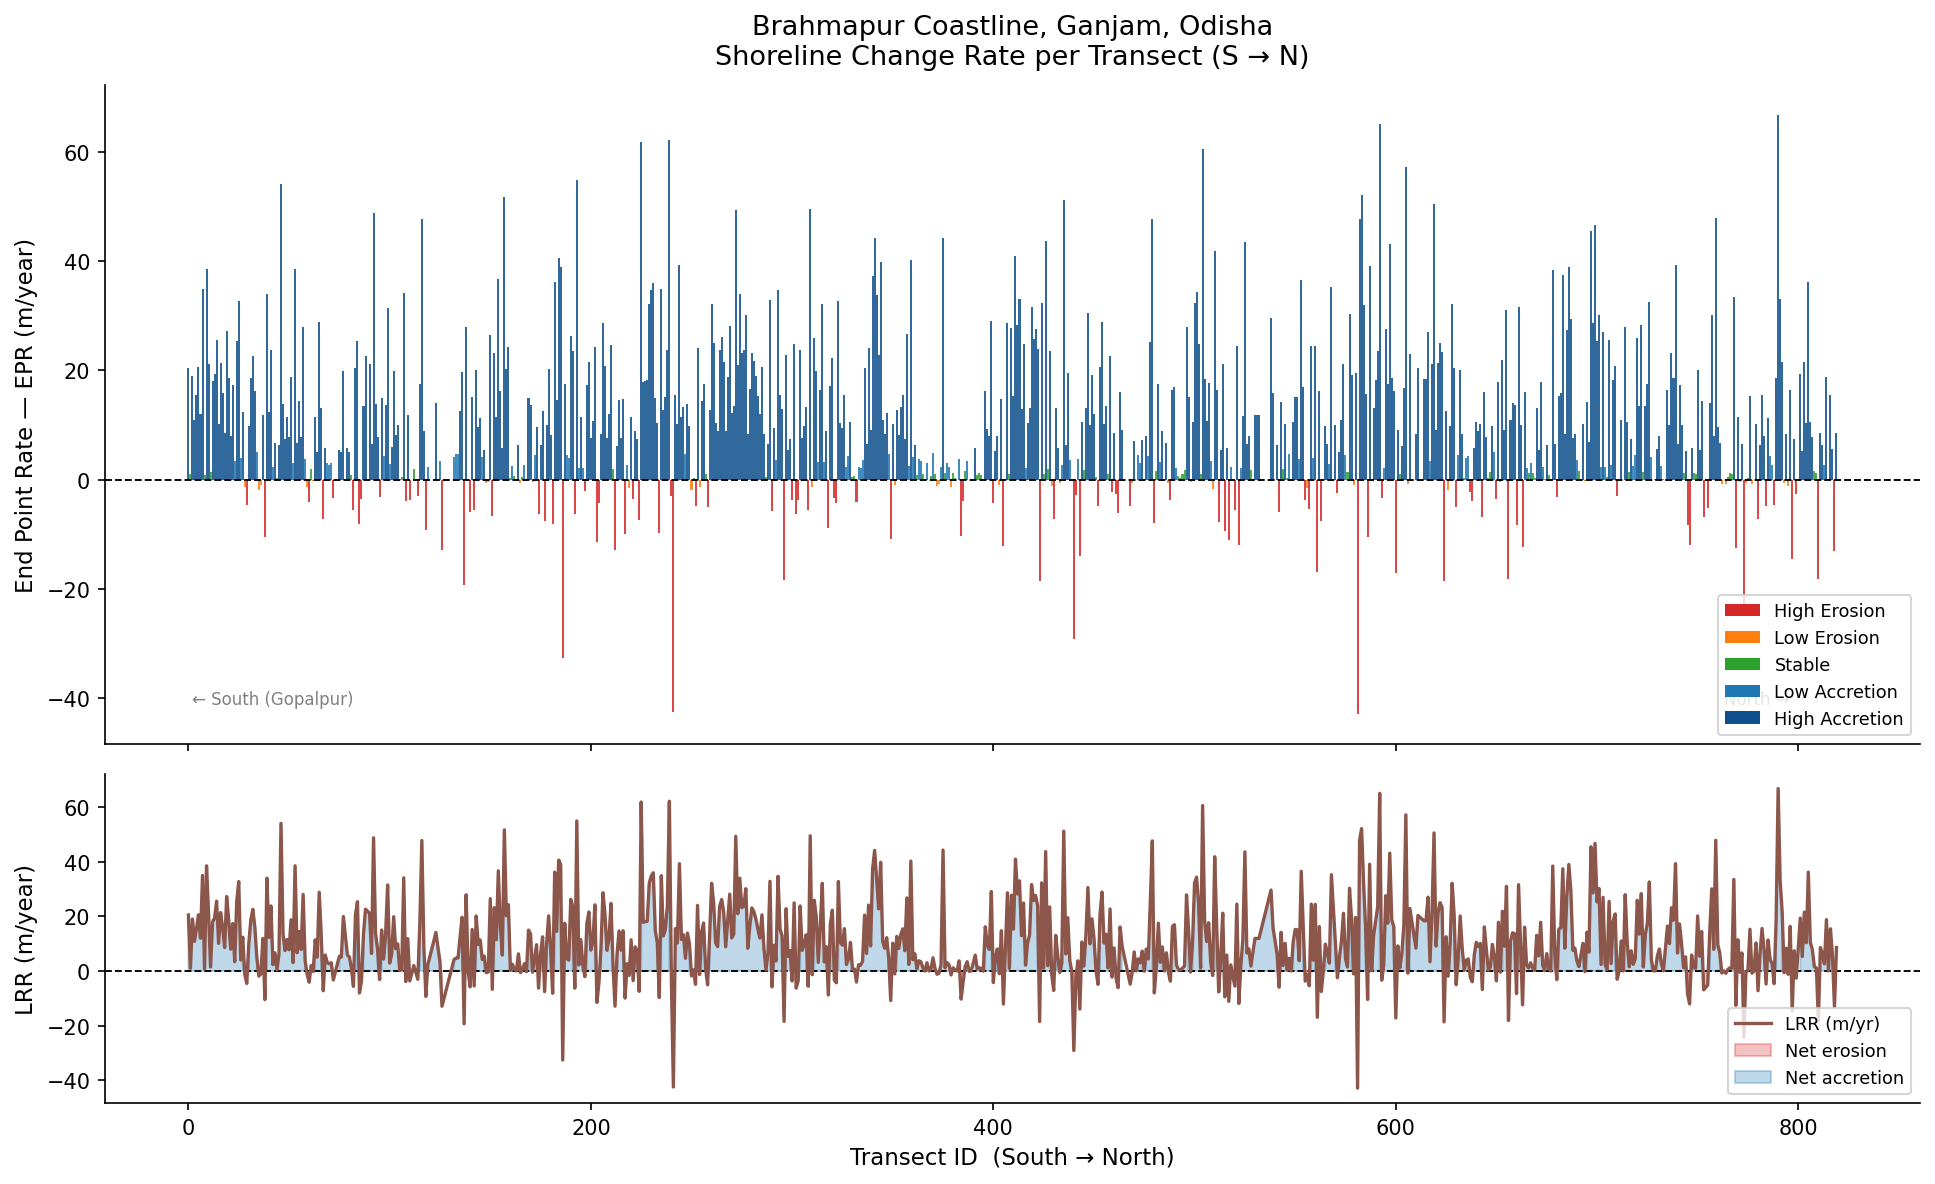

Saved: Outputs/1_shoreline_change_stats.png


In [118]:
# ─────────────────────────────────────────────────────────────────────────────
# 1D. VISUALISE — EPR BAR CHART + LRR TREND LINE
# Two-panel figure: top = per-transect EPR coloured by class,
#                   bottom = LRR with erosion/accretion fill
# ─────────────────────────────────────────────────────────────────────────────

# Colour scheme: red tones for erosion, blue for accretion, green for stable

from matplotlib.patches import Patch

CLASS_COLORS = {
    "High Erosion"    : "#D62728",
    "Low Erosion"     : "#FF7F0E",
    "Stable"          : "#2CA02C",
    "Low Accretion"   : "#1F77B4",
    "High Accretion"  : "#0D4F8B",

  
}
bar_colors = df_dsas["Classification"].map(CLASS_COLORS).fillna("#999999")

# Map each transect's classification to a bar colour
bar_colors = df_dsas["Classification"].map(CLASS_COLORS)

fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [2, 1]},   # top panel twice as tall
    sharex=True
)

# ── TOP PANEL: EPR per transect ───────────────────────────────────────────────
ax1 = axes[0]
ax1.bar(df_dsas["TransectID"], df_dsas["EPR_m_yr"],
        color=bar_colors, width=1.0, alpha=0.85, zorder=2)
ax1.axhline(0, color="black", linewidth=0.9, linestyle="--", zorder=3)  # zero baseline
ax1.set_ylabel("End Point Rate — EPR (m/year)")
ax1.set_title(f"{STUDY_AREA}\nShoreline Change Rate per Transect (S → N)", pad=10)

# Build custom legend from the colour dictionary
legend_patches = [Patch(facecolor=v, label=k) for k, v in CLASS_COLORS.items()]
ax1.legend(handles=legend_patches, fontsize=8.5, loc="lower right", framealpha=0.8)
ax1.text(2, ax1.get_ylim()[0]*0.85, "← South (Gopalpur)", fontsize=8, color="gray")
ax1.text(n_transects-20, ax1.get_ylim()[0]*0.85, "North →", fontsize=8, color="gray")

# ── BOTTOM PANEL: LRR trend with shaded zones ────────────────────────────────
ax2 = axes[1]
ax2.plot(df_dsas["TransectID"], df_dsas["LRR_m_yr"],
         color="#8C564B", linewidth=1.6, label="LRR (m/yr)", zorder=3)

# Shade regions below zero (erosion) and above zero (accretion)
ax2.fill_between(df_dsas["TransectID"], df_dsas["LRR_m_yr"], 0,
                 where=(df_dsas["LRR_m_yr"] < 0),
                 alpha=0.28, color="#D62728", label="Net erosion")
ax2.fill_between(df_dsas["TransectID"], df_dsas["LRR_m_yr"], 0,
                 where=(df_dsas["LRR_m_yr"] > 0),
                 alpha=0.28, color="#1F77B4", label="Net accretion")

ax2.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax2.set_xlabel("Transect ID  (South → North)")
ax2.set_ylabel("LRR (m/year)")
ax2.legend(fontsize=8.5, loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig("Outputs/1_shoreline_change_stats.png")
plt.show()
print("Saved: Outputs/1_shoreline_change_stats.png")


---
## Module 2 — Spectral Index Time Series (NDWI, MNDWI, NDVI, BSI)

### What are these indices?

| Index | Formula | What it detects |
|-------|---------|-----------------|
| **NDWI** | (Green − NIR) / (Green + NIR) | Open water bodies; values > 0 = water |
| **MNDWI** | (Green − SWIR) / (Green + SWIR) | Modified water index — better for coasts, reduces built-up noise |
| **NDVI** | (NIR − Red) / (NIR + Red) | Green vegetation; declining trend = coastal vegetation loss |
| **BSI** | ((SWIR+Red)−(NIR+Blue)) / ((SWIR+Red)+(NIR+Blue)) | Bare soil / sediment; rising trend = exposed sediment, erosion |

### How to get these values from GEE
In Google Earth Engine, after computing index rasters:
```javascript
// Example: export mean NDWI per year as CSV
var stats = ndwi_image.reduceRegion({
  reducer: ee.Reducer.mean(),
  geometry: aoi,
  scale: 10,
  maxPixels: 1e9
});
Export.table.toDrive({collection: stats, description: 'ndwi_2019'});
```
Repeat for each year and each index → you get 24 values (4 indices × 6 years).

### What to look for:
- **NDWI / MNDWI rising** → more water pixels = shoreline retreating landward  
- **NDVI declining** → vegetation being lost to wave action or inundation  
- **BSI rising** → more bare sediment exposed = active erosion surface


In [119]:
# ─────────────────────────────────────────────────────────────────────────────
# 2A. LOAD SPECTRAL INDEX DATA
# One row per year, one column per index (mean value across AOI)
# ─────────────────────────────────────────────────────────────────────────────

 
import pandas as pd

# Module 0 — update this
YEARS = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# ── REAL DATA ─────────────────────────────────────────────────────
df_indices = pd.read_csv("/Users/tsukki/Downloads/files/index_timeseries_12yr.csv")

# GEE exports two junk columns — drop them if present
df_indices = df_indices.drop(columns=['.geo', 'system:index'], errors='ignore')

# Make sure Year is integer and rows are sorted oldest to newest
df_indices['Year'] = df_indices['Year'].astype(int)
df_indices = df_indices.sort_values('Year').reset_index(drop=True)

# Quick sanity check
print(df_indices)

# ── Derived columns: year-on-year change rates ────────────────────────────────
# pct_change() computes (current - previous) / previous × 100
df_indices["NDVI_change_pct"] = df_indices["NDVI"].pct_change() * 100
# diff() computes absolute difference from previous row
df_indices["BSI_change"]      = df_indices["BSI"].diff()

print("Spectral Index Time Series Table:")
print(df_indices.round(4).to_string(index=False))


         BSI     MNDWI      NDVI      NDWI     Sensor  Year
0  -0.017415  0.030939  0.183558 -0.177975   Landsat8  2013
1  -0.011578 -0.007528  0.199891 -0.190629   Landsat8  2014
2   0.013970 -0.109013  0.229813 -0.229057   Landsat8  2015
3  -0.009818  0.006814  0.182629 -0.184490   Landsat8  2016
4  -0.062432  0.096263  0.160318 -0.135445  Sentinel2  2017
5  -0.031955  0.033046  0.156585 -0.141197  Sentinel2  2018
6  -0.076590  0.095871  0.162313 -0.124140  Sentinel2  2019
7  -0.084422  0.142486  0.142631 -0.105227  Sentinel2  2020
8  -0.108478  0.144847  0.161097 -0.119113  Sentinel2  2021
9  -0.057003  0.086372  0.142822 -0.116829  Sentinel2  2022
10 -0.006800 -0.105162  0.219308 -0.216311  Sentinel2  2023
11 -0.102568  0.145732  0.147812 -0.111037  Sentinel2  2024
Spectral Index Time Series Table:
    BSI   MNDWI   NDVI    NDWI    Sensor  Year  NDVI_change_pct  BSI_change
-0.0174  0.0309 0.1836 -0.1780  Landsat8  2013              NaN         NaN
-0.0116 -0.0075 0.1999 -0.1906  La

In [120]:
# ─────────────────────────────────────────────────────────────────────────────
# 2B. TREND ANALYSIS — LINEAR REGRESSION PER INDEX
# We use scipy.stats.linregress() to fit a straight line to each index over time.
# This gives: slope (rate of change per year), R², and p-value (statistical sig.)
# ─────────────────────────────────────────────────────────────────────────────

# ─── 2B. TREND ANALYSIS — LINEAR REGRESSION PER INDEX ───────────

from scipy import stats
from scipy.stats import pearsonr

print("Linear Trend Analysis (slope per year):")
print("-" * 62)

trend_results = []

for col in ["NDWI", "MNDWI", "NDVI", "BSI"]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df_indices["Year"],
        df_indices[col]
    )
    r_squared = r_value ** 2
    significance = "significant (p<0.05)" if p_value < 0.05 else  "not significant"

    print(f"  {col:8s} | slope = {slope:+.4f}/yr | R² = {r_squared:.3f} | p = {p_value:.4f} | {significance}")

    trend_results.append({
        "Index": col, "Slope_per_yr": round(slope, 5),
        "R2": round(r_squared, 4), "p_value": round(p_value, 5),
        "Significant": p_value < 0.05
    })

df_trends = pd.DataFrame(trend_results)
df_trends.to_csv("Outputs/index_trend_statistics.csv", index=False)
print("\n Saved: Outputs/index_trend_statistics.csv")
print(df_indices[["Year", "NDWI", "MNDWI", "NDVI", "BSI"]].to_string(index=False))

from scipy.stats import kendalltau
for col in ["NDWI", "MNDWI", "NDVI", "BSI"]:
    tau, p = kendalltau(df_indices["Year"], df_indices[col])
    print(f"{col}: Kendall τ = {tau:.3f}, p = {p:.4f}")

Linear Trend Analysis (slope per year):
--------------------------------------------------------------
  NDWI     | slope = +0.0060/yr | R² = 0.253 | p = 0.0957 | not significant
  MNDWI    | slope = +0.0092/yr | R² = 0.140 | p = 0.2311 | not significant
  NDVI     | slope = -0.0034/yr | R² = 0.179 | p = 0.1709 | not significant
  BSI      | slope = -0.0070/yr | R² = 0.375 | p = 0.0343 | significant (p<0.05)

 Saved: Outputs/index_trend_statistics.csv
 Year      NDWI     MNDWI     NDVI       BSI
 2013 -0.177975  0.030939 0.183558 -0.017415
 2014 -0.190629 -0.007528 0.199891 -0.011578
 2015 -0.229057 -0.109013 0.229813  0.013970
 2016 -0.184490  0.006814 0.182629 -0.009818
 2017 -0.135445  0.096263 0.160318 -0.062432
 2018 -0.141197  0.033046 0.156585 -0.031955
 2019 -0.124140  0.095871 0.162313 -0.076590
 2020 -0.105227  0.142486 0.142631 -0.084422
 2021 -0.119113  0.144847 0.161097 -0.108478
 2022 -0.116829  0.086372 0.142822 -0.057003
 2023 -0.216311 -0.105162 0.219308 -0.006800
 202

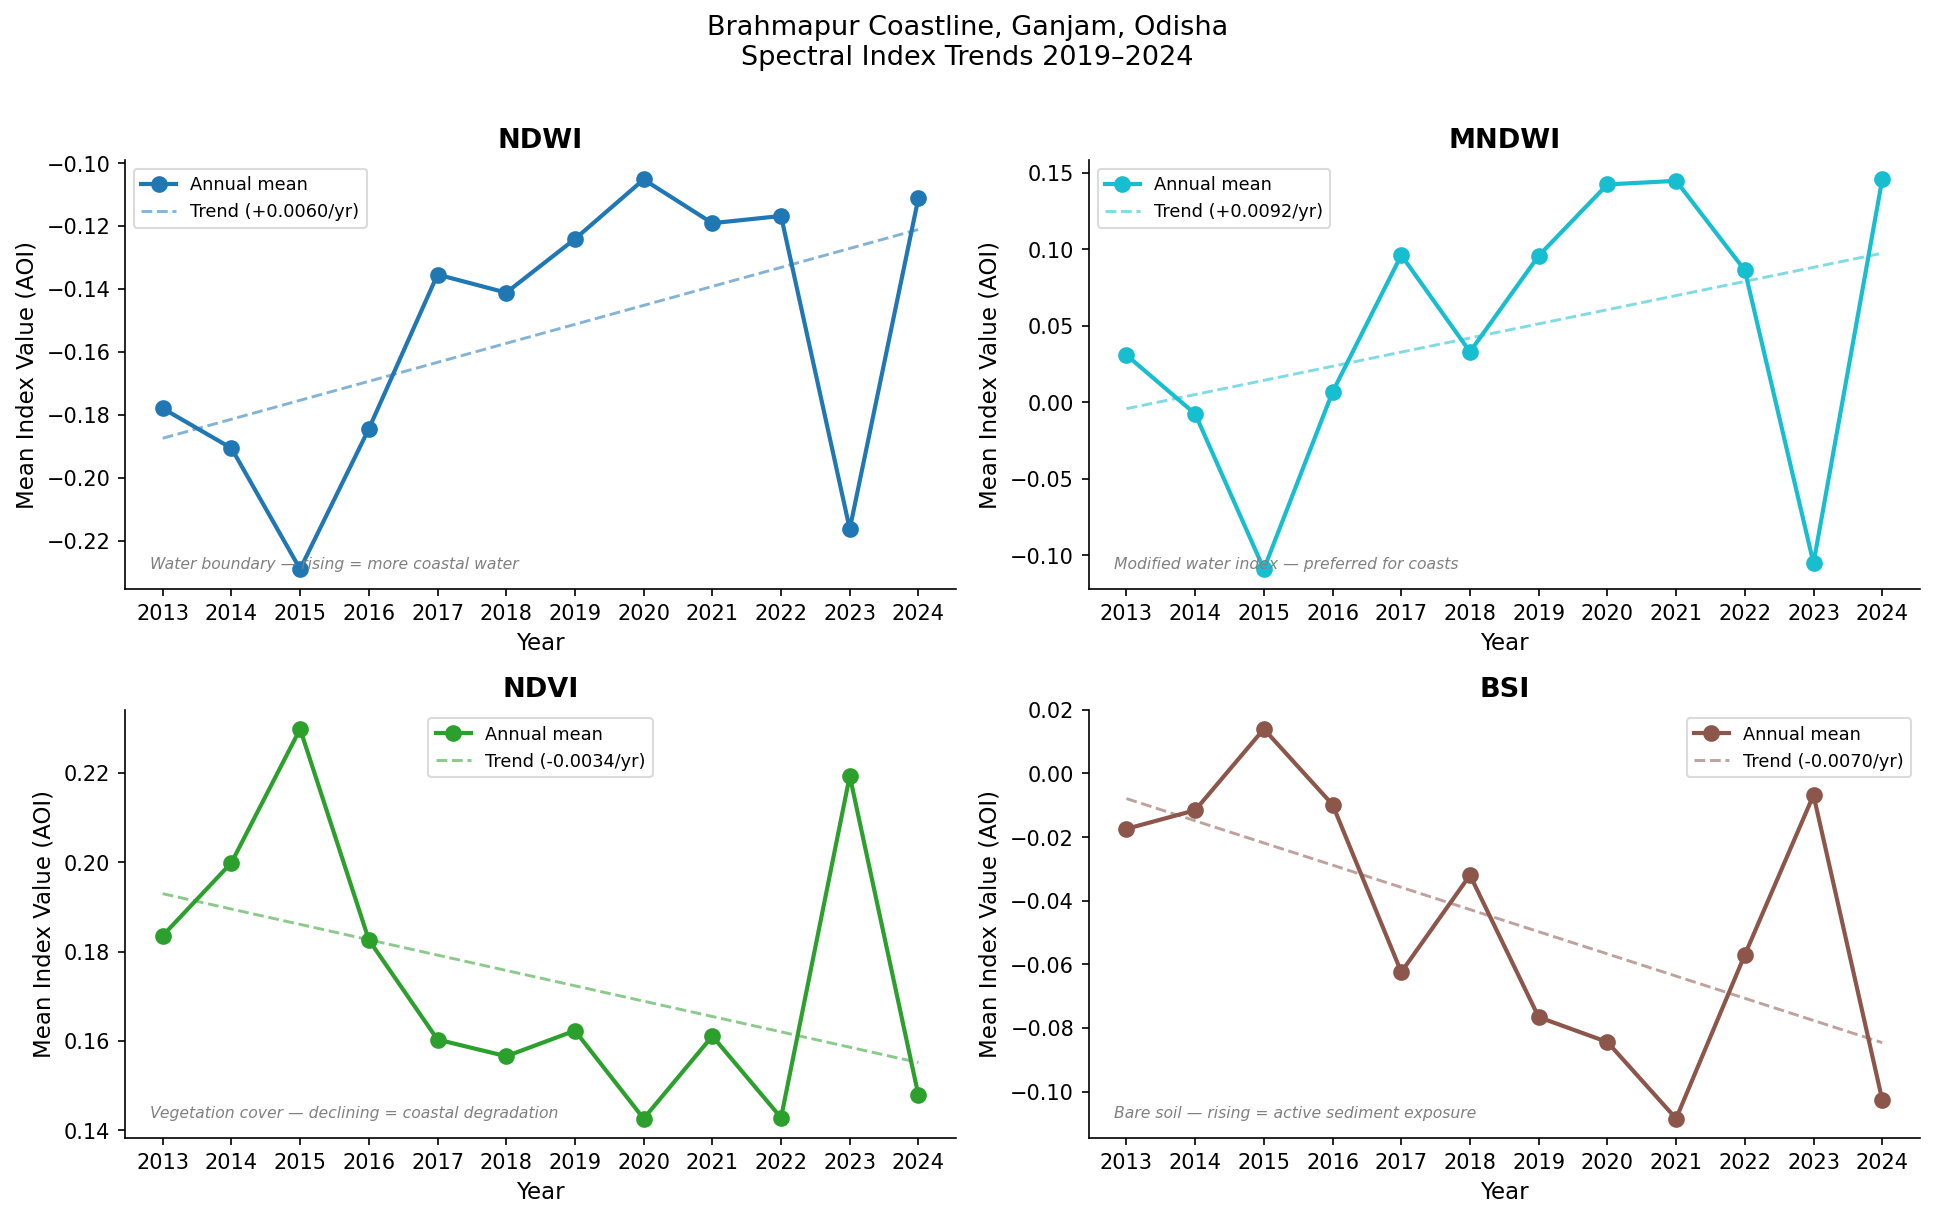

Output: Outputs/spectral_index_timeseries.png
Saved: Outputs/spectral_index_timeseries.csv


In [121]:
# ─────────────────────────────────────────────────────────────────────────────
# 2C. VISUALISE — 2×2 SUBPLOT: ONE PANEL PER INDEX
# Each panel shows actual values (dots + line) plus the regression trend (dashed)
# ─────────────────────────────────────────────────────────────────────────────

# Metadata for each index: (colour, description for annotation)

import matplotlib.pyplot as plt
import numpy as np

STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"  # Used in plot titles
index_meta = {
    "NDWI" : ("#1F77B4", "Water boundary — rising = more coastal water"),
    "MNDWI": ("#17BECF", "Modified water index — preferred for coasts"),
    "NDVI" : ("#2CA02C", "Vegetation cover — declining = coastal degradation"),
    "BSI"  : ("#8C564B", "Bare soil — rising = active sediment exposure"),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f"{STUDY_AREA}\nSpectral Index Trends 2019–2024", fontsize=13, y=1.01)

for ax, (col, (color, desc)) in zip(axes.flatten(), index_meta.items()):

    # Plot observed annual means
    ax.plot(df_indices["Year"], df_indices[col],
            marker="o", color=color, linewidth=2.0, markersize=7,
            label="Annual mean", zorder=3)

    # Compute and overlay the regression trend line
    slope, intercept, *_ = stats.linregress(df_indices["Year"], df_indices[col])
    trend_y = slope * np.array(YEARS) + intercept
    ax.plot(YEARS, trend_y, "--", color=color, alpha=0.55, linewidth=1.4,
            label=f"Trend ({slope:+.4f}/yr)")

    # Formatting
    ax.set_title(col, fontweight="bold", pad=6)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Index Value (AOI)")
    ax.set_xticks(YEARS)
    ax.legend(fontsize=8.5, framealpha=0.7)

    # Small description as a watermark-style annotation
    ax.text(0.03, 0.04, desc, transform=ax.transAxes,
            fontsize=7.5, color="gray", va="bottom", style="italic")

plt.tight_layout()
plt.savefig("Outputs/spectral_index_timeseries.png")
plt.show()
print("Output: Outputs/spectral_index_timeseries.png")
df_indices.to_csv("Outputs/spectral_index_timeseries.csv", index=False)
print("Saved: Outputs/spectral_index_timeseries.csv")


In [122]:
import geopandas as gpd
import os

years = list(range(2013, 2025))
data_folder = "/Users/tsukki/Downloads/files/GEE_Brahmapur"  # adjust if your folder name differs

for yr in years:
    path = os.path.join(data_folder, f"shoreline_{yr}.shp")
    if os.path.exists(path):
        gdf = gpd.read_file(path)
        print(f"{yr}: {len(gdf)} polygons, CRS = {gdf.crs}")
    else:
        print(f"{yr}: FILE NOT FOUND")

2013: 950 polygons, CRS = EPSG:4326
2014: 853 polygons, CRS = EPSG:4326
2015: 799 polygons, CRS = EPSG:4326
2016: 825 polygons, CRS = EPSG:4326
2017: 1696 polygons, CRS = EPSG:4326
2018: 1512 polygons, CRS = EPSG:4326
2019: 1680 polygons, CRS = EPSG:4326
2020: 1532 polygons, CRS = EPSG:4326
2021: 1757 polygons, CRS = EPSG:4326
2022: 1542 polygons, CRS = EPSG:4326
2023: 1736 polygons, CRS = EPSG:4326
2024: 1749 polygons, CRS = EPSG:4326


---
## Module 3 — Confusion Matrix & Accuracy Assessment

### Why is this needed?
Your MNDWI-based classification produces three land cover classes:
- **Water** — open sea / tidal water
- **Intertidal** — wet sand, exposed mudflat, mangrove fringe
- **Land** — stable dry land

The confusion matrix compares your **classified pixels** against **reference (truth) labels**  
collected from GPS field points or manually digitised from Google Earth high-res imagery.

### Key accuracy metrics:

| Metric | Formula | Acceptable threshold |
|--------|---------|----------------------|
| **Overall Accuracy (OA)** | (TP+TN) / Total | **> 85%** for peer-reviewed RS paper |
| **Kappa (κ)** | Agreement beyond chance | **> 0.80** = strong agreement |
| **Producer's Accuracy (PA)** | TP / Row total | How well each class is detected |
| **User's Accuracy (UA)** | TP / Column total | Reliability of each class label |




In [123]:
# ─────────────────────────────────────────────────────────────────────────────
# 3A. LOAD VALIDATION POINTS
# ─────────────────────────────────────────────────────────────────────────────



import pandas as pd
import json

df = pd.read_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/mndwi_sampled1.csv")

def predict(mndwi):
    if mndwi > 0.1:   return 'Water'
    elif mndwi > -0.1: return 'Intertidal'
    else:              return 'Land'

df['Predicted_Class'] = df['MNDWI'].apply(predict)
df.to_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/validation_points_clean_final.csv", index=False)
print("Saved: validation_points_clean_final.csv")

Saved: validation_points_clean_final.csv


In [124]:
# ─────────────────────────────────────────────────────────────────────────────
# 3B. BUILD CONFUSION MATRIX & COMPUTE ACCURACY METRICS
# ─────────────────────────────────────────────────────────────────────────────

# Define class order (consistent labelling across all outputs)
import pandas as pd

df_val = pd.read_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/validation_points_clean_final.csv")
df_val = df_val.rename(columns={'Predicted_Class': 'Predicted_Class', 'True_Class': 'True_Class'})
print(f"Loaded: {len(df_val)} points")

CLASSES = ["Water", "Intertidal", "Land"]

# sklearn confusion_matrix: rows = true class, columns = predicted class
cm = confusion_matrix(df_val["True_Class"], df_val["Predicted_Class"], labels=CLASSES)

# Wrap in DataFrame for readable display
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
cm_df.index.name   = "True Class →"
cm_df.columns.name = "Predicted Class ↓"

# ── Overall Accuracy ──────────────────────────────────────────────────────────
# Diagonal elements = correctly classified; divide by total points
overall_acc = np.trace(cm) / cm.sum()

# ── Cohen's Kappa ─────────────────────────────────────────────────────────────
# Adjusts for agreement expected by chance alone
kappa = cohen_kappa_score(df_val["True_Class"], df_val["Predicted_Class"])

# ── Per-class Producer's and User's Accuracy ─────────────────────────────────
# PA = TP / total true instances of that class (row sum)  → detection rate
# UA = TP / total predicted as that class (col sum)       → reliability
prod_acc = {c: cm[i, i] / cm[i, :].sum() for i, c in enumerate(CLASSES)}
user_acc = {c: cm[i, i] / cm[:, i].sum() for i, c in enumerate(CLASSES)}

# ── Print results ─────────────────────────────────────────────────────────────
print("CONFUSION MATRIX:")
print(cm_df.to_string())
print(f"\nOverall Accuracy (OA) : {overall_acc*100:.2f}%  (threshold: >85%)")
print(f"Kappa Coefficient (κ) : {kappa:.4f}      (threshold: >0.80)")

acc_table = pd.DataFrame({
    "Class"  : CLASSES,
    "PA (%)" : [round(prod_acc[c]*100, 1) for c in CLASSES],
    "UA (%)" : [round(user_acc[c]*100, 1) for c in CLASSES],
})
print("\nPer-class Accuracy:")
print(acc_table.to_string(index=False))


Loaded: 180 points
CONFUSION MATRIX:
Predicted Class ↓  Water  Intertidal  Land
True Class →                              
Water                 54           8     1
Intertidal            17          49     0
Land                   3           4    44

Overall Accuracy (OA) : 81.67%  (threshold: >85%)
Kappa Coefficient (κ) : 0.7227      (threshold: >0.80)

Per-class Accuracy:
     Class  PA (%)  UA (%)
     Water    85.7    73.0
Intertidal    74.2    80.3
      Land    86.3    97.8


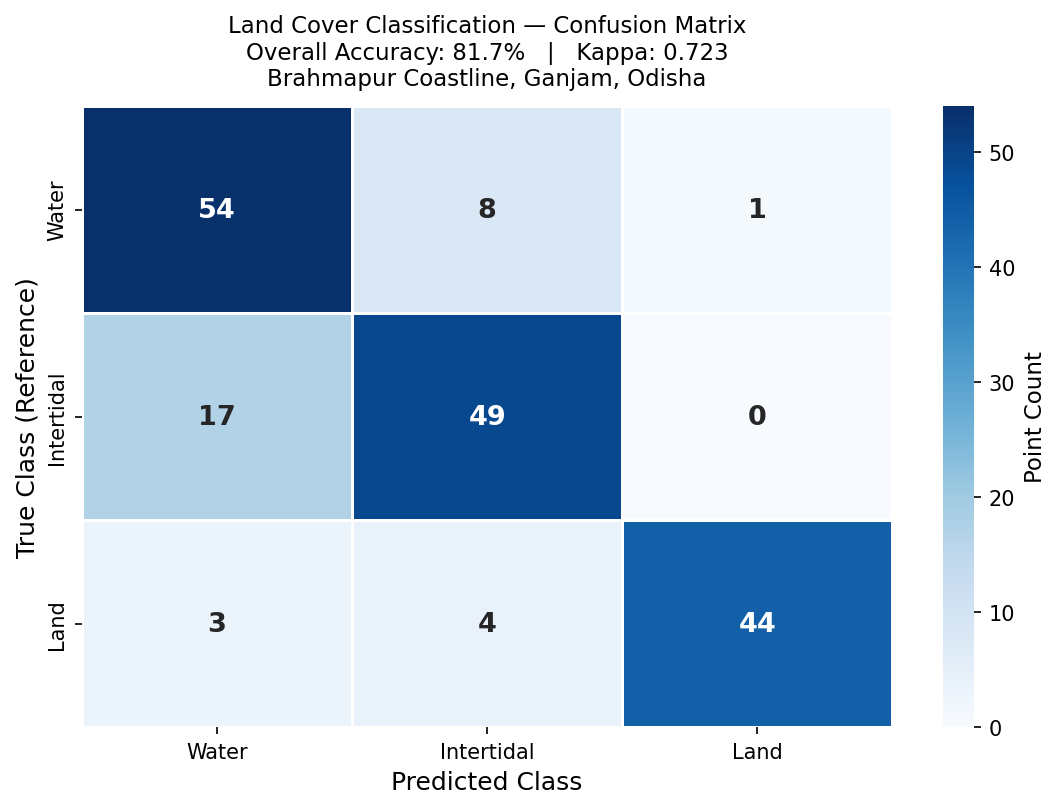

✅ Saved: outputs/3_confusion_matrix.png
✅ Saved: outputs/validation_points.csv
✅ Saved: outputs/accuracy_assessment.csv


In [125]:
# ─────────────────────────────────────────────────────────────────────────────
# 3C. VISUALISE — CONFUSION MATRIX HEATMAP
# Annotated heatmap with count values + accuracy metrics in title
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# sns.heatmap: annot=True puts count values inside each cell
# fmt="d" means display as integer (not scientific notation)
# cmap="Blues" → light = low, dark = high (diagonal should be darkest)
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Point Count"},
    annot_kws={"size": 13, "weight": "bold"}
)

ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("True Class (Reference)", fontsize=12)
ax.set_title(
    f"Land Cover Classification — Confusion Matrix\n"
    f"Overall Accuracy: {overall_acc*100:.1f}%   |   Kappa: {kappa:.3f}\n"
    f"{STUDY_AREA}",
    fontsize=11, pad=10
)

plt.tight_layout()
plt.savefig("outputs/3_confusion_matrix.png")
plt.show()

# Save tabular results
df_val.to_csv("outputs/validation_points.csv", index=False)
acc_table.to_csv("outputs/accuracy_assessment.csv", index=False)
print("✅ Saved: outputs/3_confusion_matrix.png")
print("✅ Saved: outputs/validation_points.csv")
print("✅ Saved: outputs/accuracy_assessment.csv")


---
## Module 4 — Erosion Hotspot Classification

### What is this?
This module builds a **composite erosion risk score** per transect by combining three  
independent lines of evidence into a single 0–1 risk score:

| Component | Weight | Rationale |
|-----------|--------|-----------|
| LRR rate | **50%** | Primary physical measure of shoreline change |
| NDVI decline | **30%** | Vegetation loss precedes/accompanies erosion |
| BSI level | **20%** | Active bare sediment is a direct erosion indicator |

### Risk classification:

| Risk Level | Score range | Management implication |
|------------|-------------|------------------------|
| **Critical** | ≥ 0.75 | Immediate intervention (seawalls, mangrove planting) |
| **High** | 0.55 – 0.74 | Priority monitoring; 1-year revisit |
| **Moderate** | 0.35 – 0.54 | Annual monitoring |
| **Low** | 0.15 – 0.34 | 3-year revisit sufficient |
| **Negligible** | < 0.15 | No intervention needed |


In [126]:
# ─────────────────────────────────────────────────────────────────────────────
# 4A. BUILD COMPOSITE RISK SCORE PER TRANSECT
# ─────────────────────────────────────────────────────────────────────────────

# Start with the DSAS DataFrame (already has LRR, position info)
df_risk = df_dsas[["TransectID", "Longitude", "Latitude",
                   "LRR_m_yr", "EPR_m_yr", "NSM_m"]].copy()

# ── Add per-transect spectral values ─────────────────────────────────────────
# In real analysis: use geopandas spatial join to assign index values
# to each transect point from your index GeoTIFF rasters.
# Example:
#   gdf_transects = gpd.read_file("data/transects.shp")
#   gdf_transects = gdf_transects.merge(index_zonal_stats, on="TransectID")

np.random.seed(13)

# Simulate realistic NDVI values: higher inland, lower near water
df_risk["NDVI_2019"] = np.random.uniform(0.30, 0.55, n_transects)

# NDVI in 2024 declines more where erosion rate is higher
df_risk["NDVI_2024"] = (
    df_risk["NDVI_2019"]
    - np.abs(df_risk["LRR_m_yr"]) * 0.05   # erosion accelerates NDVI loss
    + np.random.normal(0, 0.02, n_transects)
)

# BSI inversely correlated with NDVI (more vegetation = less bare soil)
df_risk["BSI_2024"] = (
    -df_risk["NDVI_2024"] * 0.6
    + np.random.normal(0, 0.03, n_transects)
)

# NDVI decline = how much vegetation was lost 2019 → 2024
df_risk["NDVI_decline"] = df_risk["NDVI_2019"] - df_risk["NDVI_2024"]

print("Spectral values assigned to all transects.")
df_risk[["TransectID","LRR_m_yr","NDVI_2019","NDVI_2024","NDVI_decline","BSI_2024"]].head(8)


Spectral values assigned to all transects.


,TransectID,LRR_m_yr,NDVI_2019,NDVI_2024,NDVI_decline,BSI_2024
0,0,20.4846,0.494426,-0.535472,1.029897,0.317483
1,1,1.0086,0.359385,0.320435,0.038950,-0.214805
2,2,18.9953,0.506070,-0.447141,0.953210,0.228283
3,3,10.8477,0.541437,0.001110,0.540327,-0.014025
4,4,15.4618,0.543150,-0.227697,0.770848,0.140382
5,5,20.5814,0.413362,-0.650323,1.063686,0.357500
6,6,11.9824,0.452261,-0.133335,0.585595,0.075819
7,7,34.9565,0.493882,-1.239440,1.733322,0.728281


In [127]:
# ─────────────────────────────────────────────────────────────────────────────
# 4B. NORMALISE EACH COMPONENT AND COMPUTE WEIGHTED RISK SCORE
# ─────────────────────────────────────────────────────────────────────────────

def normalise(series):
    """
    Min-max normalisation: rescales a Series to the range [0, 1].
    0 = lowest risk from that component, 1 = highest risk.
    """
    return (series - series.min()) / (series.max() - series.min())

# LRR component: more negative LRR = higher erosion risk, so invert with minus
df_risk["score_lrr"]  = normalise(-df_risk["LRR_m_yr"])

# NDVI decline component: larger decline = higher risk
df_risk["score_ndvi"] = normalise(df_risk["NDVI_decline"])

# BSI component: higher BSI (more bare soil) = higher risk
df_risk["score_bsi"]  = normalise(df_risk["BSI_2024"])

# Weighted linear combination — weights sum to 1.0
df_risk["Risk_Score"] = (
    0.50 * df_risk["score_lrr"]   +   # 50% weight to LRR (primary evidence)
    0.30 * df_risk["score_ndvi"]  +   # 30% weight to NDVI decline
    0.20 * df_risk["score_bsi"]       # 20% weight to BSI exposure
)

# ── Classify into five risk levels ───────────────────────────────────────────
def risk_class(score):
    if   score >= 0.75: return "Critical"
    elif score >= 0.55: return "High"
    elif score >= 0.35: return "Moderate"
    elif score >= 0.15: return "Low"
    else:               return "Negligible"

df_risk["Risk_Level"] = df_risk["Risk_Score"].apply(risk_class)

# ── Summary table ─────────────────────────────────────────────────────────────
risk_summary = df_risk["Risk_Level"].value_counts().reset_index()
risk_summary.columns = ["Risk Level", "Transect_Count"]
risk_summary["Pct_of_Coast"] = (risk_summary["Transect_Count"] / n_transects * 100).round(1)

print("Erosion Hotspot Summary:")
print(risk_summary.to_string(index=False))


Erosion Hotspot Summary:
Risk Level  Transect_Count  Pct_of_Coast
  Moderate             395          50.4
       Low             383          48.9
      High               3           0.4
  Critical               2           0.3


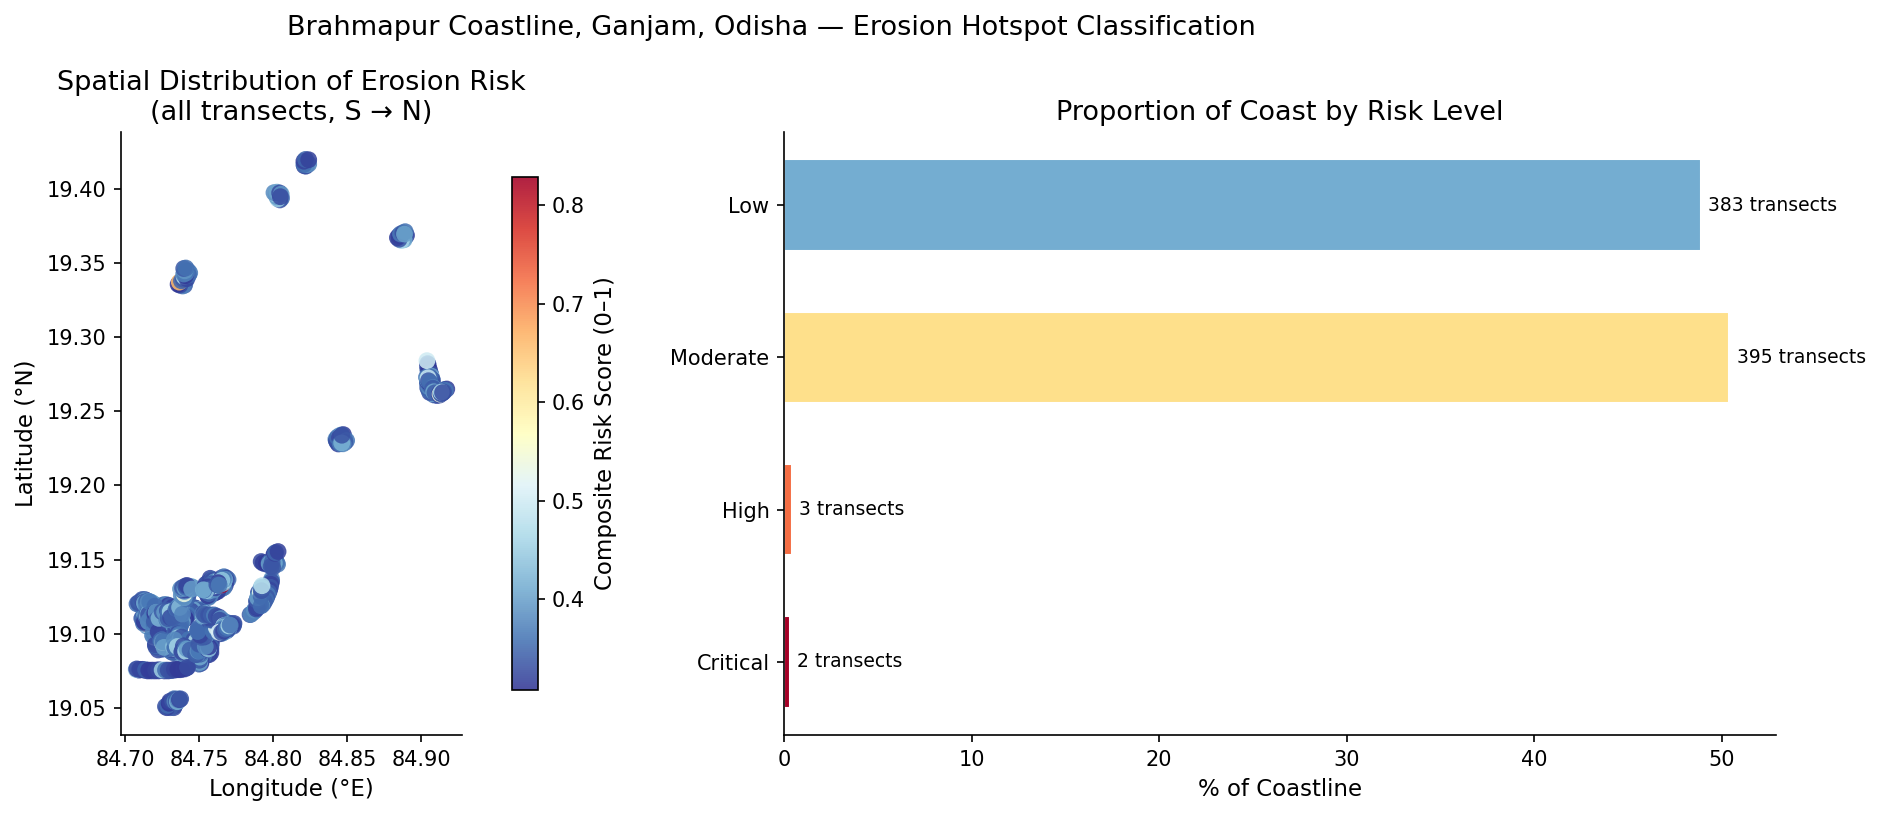

✅ Saved: outputs/4_erosion_hotspot_classification.png
✅ Saved: outputs/erosion_hotspot_table.csv


In [128]:
# ─────────────────────────────────────────────────────────────────────────────
# 4C. VISUALISE — SPATIAL RISK MAP + CLASSIFICATION BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

# Risk colour scale: diverging from blue (safe) → red (critical)
RISK_COLORS = {
    "Critical"  : "#A50026",   # deep red
    "High"      : "#F46D43",   # orange-red
    "Moderate"  : "#FEE08B",   # yellow
    "Low"       : "#74ADD1",   # light blue
    "Negligible": "#313695",   # deep blue
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f"{STUDY_AREA} — Erosion Hotspot Classification", fontsize=13)

# ── LEFT: Spatial scatter map of risk scores ─────────────────────────────────
ax1 = axes[0]
sc = ax1.scatter(
    df_risk["Longitude"], df_risk["Latitude"],
    c=df_risk["Risk_Score"],    # colour by continuous risk score
    cmap="RdYlBu_r",            # red = high risk, blue = low risk
    s=65, alpha=0.87, edgecolors="none", zorder=3
)
cbar = plt.colorbar(sc, ax=ax1, shrink=0.85)
cbar.set_label("Composite Risk Score (0–1)")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.set_title("Spatial Distribution of Erosion Risk\n(all transects, S → N)")
ax1.set_aspect("equal")  # Preserve geographic proportions

# ── RIGHT: Bar chart of risk level proportions ────────────────────────────────
ax2 = axes[1]
ordered_levels = ["Critical", "High", "Moderate", "Low", "Negligible"]

# Reorder summary table to match our preferred display order
risk_plot = risk_summary.set_index("Risk Level").reindex(ordered_levels).reset_index().dropna()

bars = ax2.barh(
    risk_plot["Risk Level"],
    risk_plot["Pct_of_Coast"],
    color=[RISK_COLORS[r] for r in risk_plot["Risk Level"]],
    edgecolor="white", height=0.6
)
ax2.set_xlabel("% of Coastline")
ax2.set_title("Proportion of Coast by Risk Level")

# Annotate each bar with transect count
for i, (pct, count) in enumerate(zip(risk_plot["Pct_of_Coast"], risk_plot["Transect_Count"])):
    ax2.text(pct + 0.4, i, f"{int(count)} transects", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/4_erosion_hotspot_classification.png")
plt.show()

df_risk.to_csv("outputs/erosion_hotspot_table.csv", index=False)
print("✅ Saved: outputs/4_erosion_hotspot_classification.png")
print("✅ Saved: outputs/erosion_hotspot_table.csv")


---
## Module 5 — Correlation: Erosion vs Climate Drivers

### Why correlate with climate data?
Understanding *what drives* erosion is as important as measuring it.  
This module tests whether years with heavier rainfall, higher waves, or more  
cyclone activity correlate with higher erosion rates.

### Data sources for real data:
| Variable | Source | URL |
|----------|--------|-----|
| Monsoon rainfall | India Meteorological Department (IMD) | imd.gov.in |
| Wave height | INCOIS | incois.gov.in/waves |
| Cyclone tracks | IMD Cyclone eAtlas | rsmcnewdelhi.imd.gov.in |

### Statistical test used: Pearson Correlation
- **r = −1**: perfect negative correlation (more rainfall = more erosion)
- **r = 0**: no linear relationship
- **r = +1**: perfect positive correlation
- **p < 0.05**: statistically significant

> ⚠️ **Note on sample size:** With only 6 data points (years), even strong correlations  
> can be statistically fragile. This analysis is **exploratory** — report it as a  
> preliminary finding and recommend longer time series for confirmation.


In [129]:
# ─────────────────────────────────────────────────────────────────────────────
# 5A. LOAD CLIMATE & AUXILIARY DATA
# ─────────────────────────────────────────────────────────────────────────────


import pandas as pd

df_climate = pd.read_csv("/Users/tsukki/Downloads/files/GEE_Brahmapur/climate_combined.csv")

# Rename to match notebook's expected variable names
df_climate = df_climate.rename(columns={
    'Rainfall_mm': 'Rainfall_mm',
    'Sig_Wave_Height_m': 'Sig_Wave_Height_m',
    'Storm_Days': 'Storm_Days',
    'Cyclone_Intensity': 'Cyclone_Intensity',
    'Mean_NDVI': 'Mean_NDVI',
    'Mean_BSI': 'Mean_BSI',
    'Mean_EPR_m_yr': 'Mean_EPR_m_yr'
})

YEARS = df_climate['Year'].tolist()

print("Climate + Erosion Combined Table:")
print(df_climate.round(3).to_string(index=False))


Climate + Erosion Combined Table:
 Year  Rainfall_mm  Sig_Wave_Height_m  Storm_Days  Cyclone_Intensity  Mean_NDVI  Mean_BSI  Mean_EPR_m_yr
 2013       1577.5              1.068           8                  3      0.184    -0.017          14.75
 2014       1458.9              1.092           2                  1      0.200    -0.012          16.65
 2015       1278.0              1.089           1                  0      0.230     0.014          25.00
 2016       1146.6              1.204           2                  1      0.183    -0.010          17.23
 2017       1478.6              1.499           1                  0      0.160    -0.062           0.04
 2018       1955.9              1.491           5                  3      0.157    -0.032          10.00
 2019       1528.1              1.394           3                  2      0.162    -0.077          -4.58
 2020       1211.6              1.396           4                  2      0.143    -0.084          -7.14
 2021       1456.8   

In [130]:
# ─────────────────────────────────────────────────────────────────────────────
# 5B. PEARSON CORRELATION — EACH CLIMATE VARIABLE vs. MEAN EPR
# ─────────────────────────────────────────────────────────────────────────────

print("Pearson Correlations — Climate Drivers vs Mean Shoreline Change Rate:")
print("-" * 70)

CLIMATE_VARS = ["Rainfall_mm", "Sig_Wave_Height_m", "Storm_Days", "Cyclone_Intensity"]
corr_results = []

for var in CLIMATE_VARS:
    # pearsonr returns the correlation coefficient (r) and two-tailed p-value
    r, p = pearsonr(df_climate[var], df_climate["Mean_EPR_m_yr"])
    sig = "✅ significant" if p < 0.05 else "⚠️  not significant"

    print(f"  {var:25s} | r = {r:+.3f} | p = {p:.4f} | {sig}")
    corr_results.append({
        "Variable"    : var,
        "r"           : round(r, 4),
        "p_value"     : round(p, 5),
        "Significant" : p < 0.05,
        "Interpretation": "More intense → more erosion" if r < -0.5 else
                          "Positive driver" if r > 0.5 else "Weak relationship"
    })

df_corr = pd.DataFrame(corr_results)
df_corr.to_csv("outputs/correlation_results.csv", index=False)
print("\n✅ Saved: outputs/correlation_results.csv")


Pearson Correlations — Climate Drivers vs Mean Shoreline Change Rate:
----------------------------------------------------------------------
  Rainfall_mm               | r = -0.349 | p = 0.2657 | ⚠️  not significant
  Sig_Wave_Height_m         | r = -0.617 | p = 0.0327 | ✅ significant
  Storm_Days                | r = +0.232 | p = 0.4685 | ⚠️  not significant
  Cyclone_Intensity         | r = +0.121 | p = 0.7088 | ⚠️  not significant

✅ Saved: outputs/correlation_results.csv


In [131]:
# ─────────────────────────────────────────────────────────────────────────────
# 5C. FULL CORRELATION MATRIX (all variables vs all)
# ─────────────────────────────────────────────────────────────────────────────

# Select the numeric columns to include in the full matrix
corr_cols = ["Mean_EPR_m_yr", "Rainfall_mm", "Sig_Wave_Height_m",
             "Storm_Days", "Mean_NDVI", "Mean_BSI"]

corr_matrix = df_climate[corr_cols].corr()

print("Full Correlation Matrix:")
print(corr_matrix.round(3).to_string())


Full Correlation Matrix:
                   Mean_EPR_m_yr  Rainfall_mm  Sig_Wave_Height_m  Storm_Days  Mean_NDVI  Mean_BSI
Mean_EPR_m_yr              1.000       -0.349             -0.617       0.232      0.814     1.000
Rainfall_mm               -0.349        1.000              0.291       0.134     -0.422    -0.349
Sig_Wave_Height_m         -0.617        0.291              1.000      -0.084     -0.524    -0.617
Storm_Days                 0.232        0.134             -0.084       1.000      0.139     0.232
Mean_NDVI                  0.814       -0.422             -0.524       0.139      1.000     0.814
Mean_BSI                   1.000       -0.349             -0.617       0.232      0.814     1.000


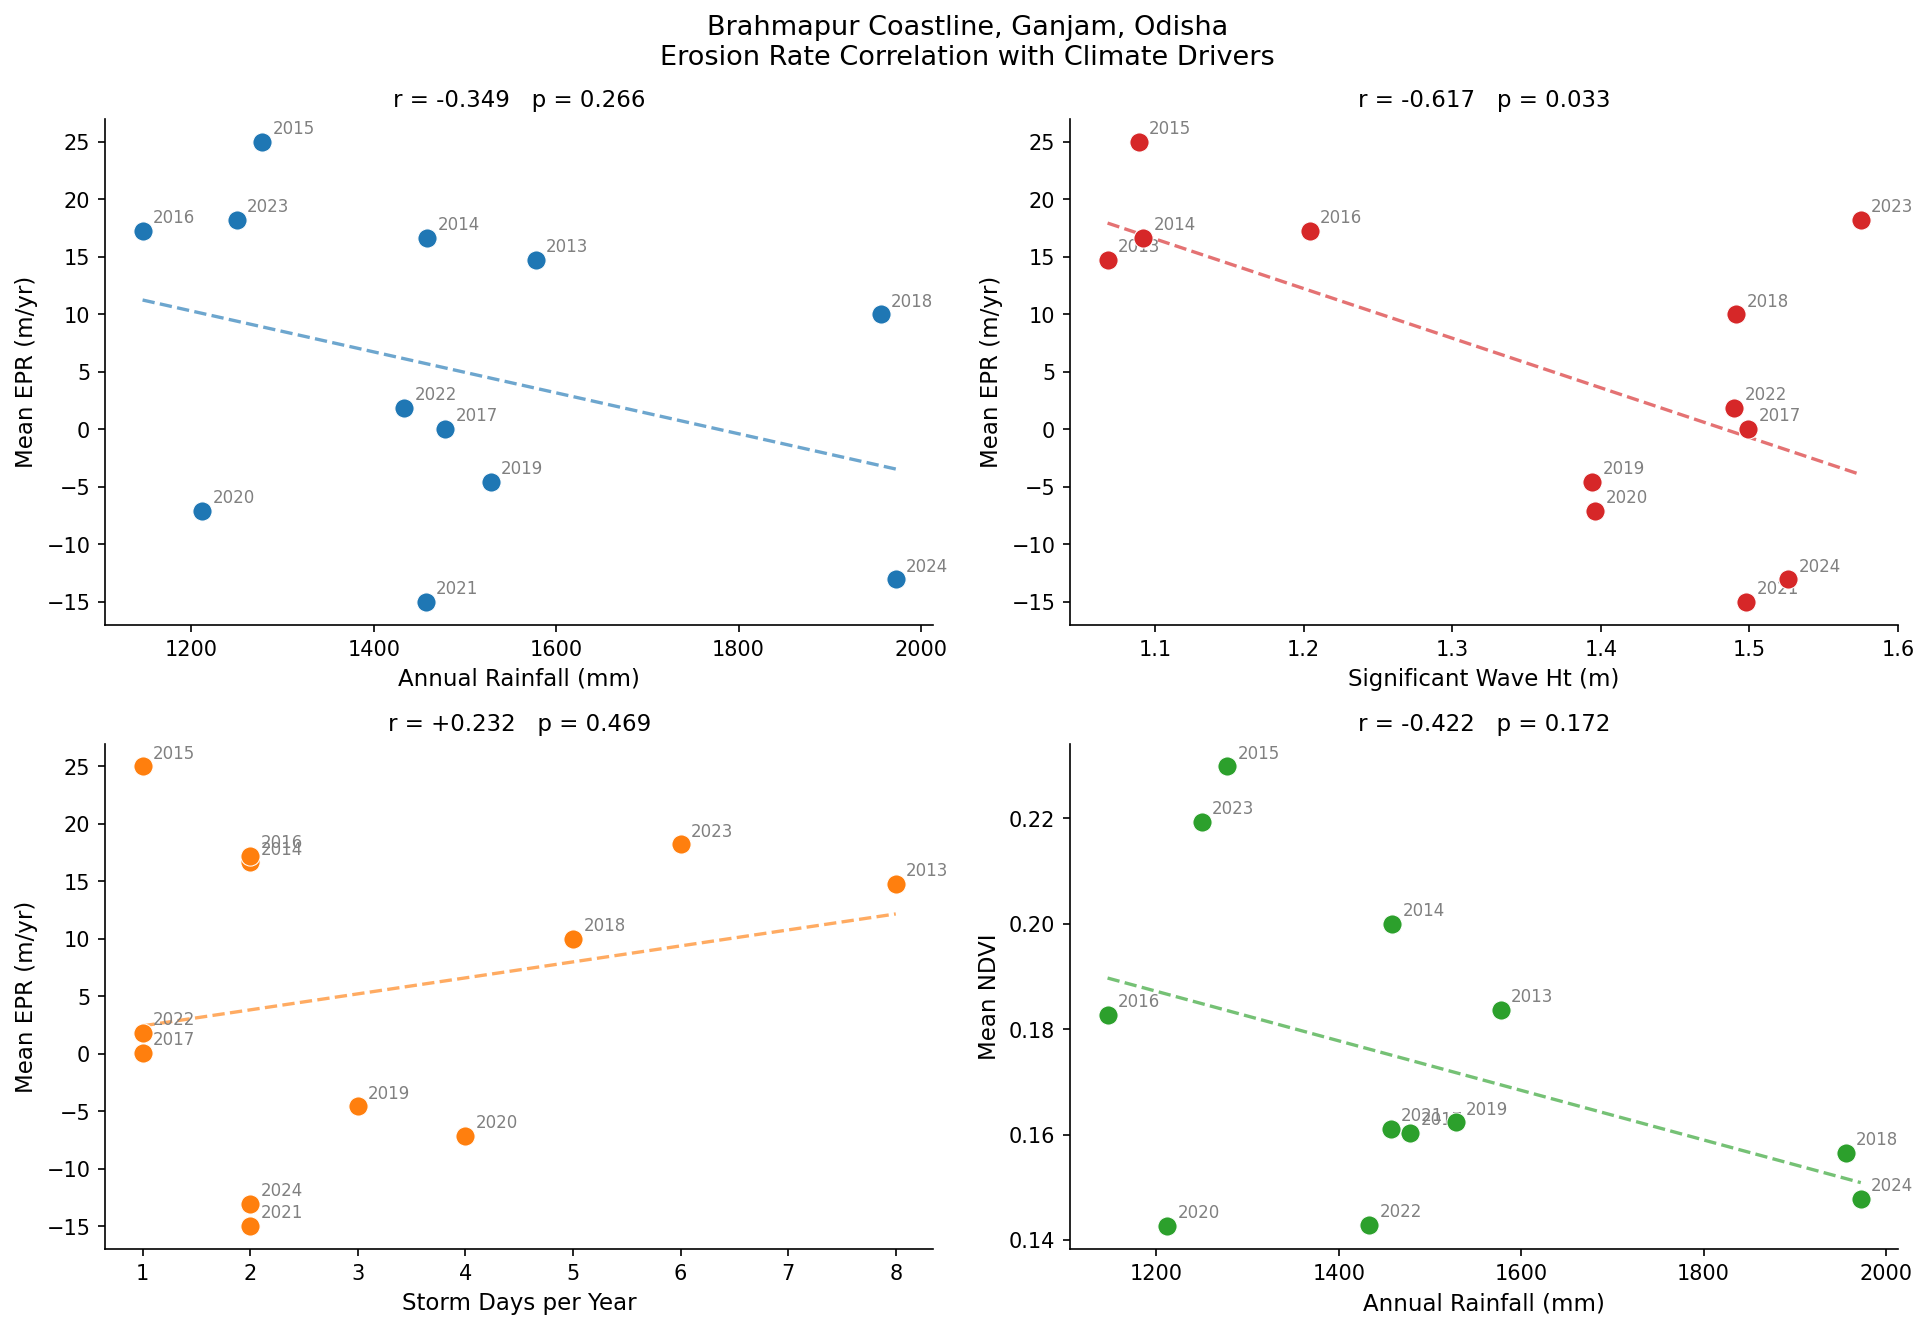

✅ Saved: outputs/5a_correlation_scatter.png


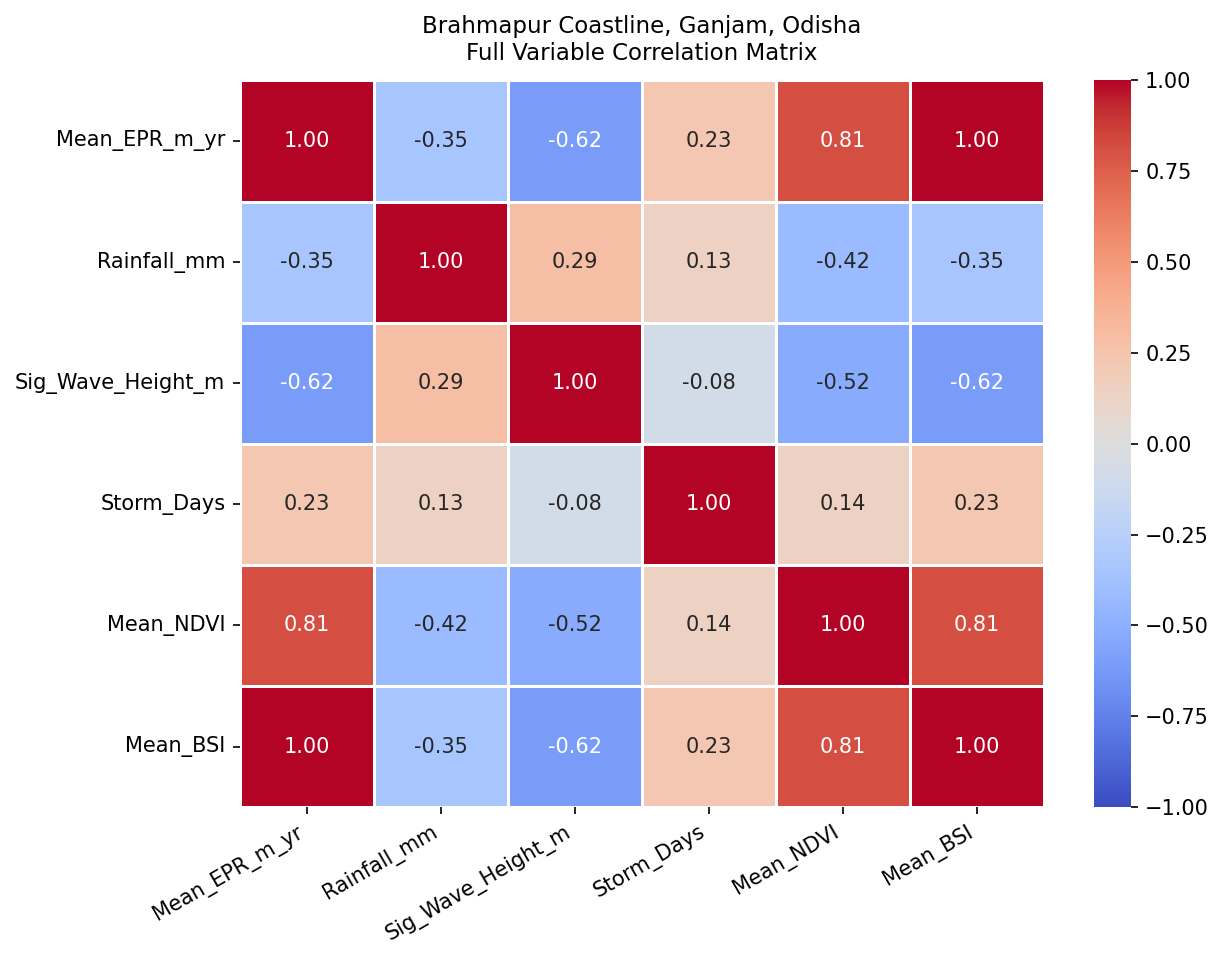

✅ Saved: outputs/5b_correlation_matrix.png
✅ Saved: outputs/climate_erosion_data.csv


In [132]:
# ─────────────────────────────────────────────────────────────────────────────
# 5D. VISUALISE — SCATTER PLOTS + CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────────────────────

# ── Figure 1: 4 scatter plots with regression lines ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"{STUDY_AREA}\nErosion Rate Correlation with Climate Drivers",
    fontsize=13
)

scatter_pairs = [
    ("Rainfall_mm",       "Mean_EPR_m_yr", "Annual Rainfall (mm)",     "Mean EPR (m/yr)", "#1F77B4"),
    ("Sig_Wave_Height_m", "Mean_EPR_m_yr", "Significant Wave Ht (m)",  "Mean EPR (m/yr)", "#D62728"),
    ("Storm_Days",        "Mean_EPR_m_yr", "Storm Days per Year",       "Mean EPR (m/yr)", "#FF7F0E"),
    ("Rainfall_mm",       "Mean_NDVI",     "Annual Rainfall (mm)",      "Mean NDVI",       "#2CA02C"),
]

for ax, (xvar, yvar, xlabel, ylabel, color) in zip(axes.flatten(), scatter_pairs):

    # Plot data points
    ax.scatter(df_climate[xvar], df_climate[yvar],
               color=color, s=85, zorder=4, edgecolors="white", linewidth=0.5)

    # Annotate each point with its year label
    for _, row in df_climate.iterrows():
        ax.annotate(
            str(int(row["Year"])),
            (row[xvar], row[yvar]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8, color="gray"
        )

    # Fit and draw regression line
    slope, intercept, r_val, p_val, _ = stats.linregress(
        df_climate[xvar], df_climate[yvar]
    )
    x_line = np.linspace(df_climate[xvar].min(), df_climate[xvar].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            "--", color=color, alpha=0.65, linewidth=1.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"r = {r_val:+.3f}   p = {p_val:.3f}", fontsize=11)

plt.tight_layout()
plt.savefig("outputs/5a_correlation_scatter.png")
plt.show()
print("✅ Saved: outputs/5a_correlation_scatter.png")

# ── Figure 2: Full correlation matrix heatmap ────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 6.5))

sns.heatmap(
    corr_matrix,
    annot=True,               # Print r values inside each cell
    fmt=".2f",                # 2 decimal places
    cmap="coolwarm",          # Red = strong positive, Blue = strong negative
    center=0,                 # White = zero correlation
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1,          # Fix colour scale to full correlation range
    annot_kws={"size": 10}
)
ax.set_title(
    f"{STUDY_AREA}\nFull Variable Correlation Matrix",
    fontsize=11, pad=10
)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/5b_correlation_matrix.png")
plt.show()
print("✅ Saved: outputs/5b_correlation_matrix.png")

df_climate.to_csv("outputs/climate_erosion_data.csv", index=False)
print("✅ Saved: outputs/climate_erosion_data.csv")


---
## Module 6 — Paper-Ready Summary Table

This final module assembles **all key results** from Modules 1–5 into a single  
clean summary table — formatted for direct inclusion in your research paper's  
**Results** section.

Copy the CSV output (`outputs/summary_results_table.csv`) directly into your  
Word / LaTeX document.


In [133]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. MASTER SUMMARY TABLE
# Pulls computed values from all previous modules — no new calculation here
# ─────────────────────────────────────────────────────────────────────────────

summary_paper = pd.DataFrame({
    "Metric": [
        # ── Module 1: Shoreline change ────────────────────────────────────────
        "Total transects analysed",
        "Mean LRR (m/yr)",
        "Max erosion rate EPR (m/yr)",
        "Max accretion rate EPR (m/yr)",
        "% coastline under net erosion",
        "% coastline Critical or High risk",

        # ── Module 2: Spectral indices ────────────────────────────────────────
        "NDVI change 2019–2024",
        "BSI change 2019–2024",
        "NDVI trend significance",
        "BSI trend significance",

        # ── Module 3: Accuracy ────────────────────────────────────────────────
        "Overall classification accuracy (OA)",
        "Cohen's Kappa coefficient (κ)",
        "Intertidal Producer's Accuracy (hardest class)",

        # ── Module 5: Correlation ─────────────────────────────────────────────
        "Strongest erosion driver",
        "Correlation with wave height (r)",
        "Correlation with storm days (r)",
    ],
    "Value": [
        str(n_transects),
        f"{df_dsas['LRR_m_yr'].mean():.2f} m/yr",
        f"{df_dsas['EPR_m_yr'].min():.2f} m/yr",
        f"{df_dsas['EPR_m_yr'].max():.2f} m/yr",
        f"{(df_dsas['LRR_m_yr'] < 0).mean()*100:.1f}%",
        f"{df_risk['Risk_Level'].isin(['Critical','High']).mean()*100:.1f}%",

        f"{df_indices['NDVI'].iloc[-1] - df_indices['NDVI'].iloc[0]:.3f}",
        f"{df_indices['BSI'].iloc[-1]  - df_indices['BSI'].iloc[0]:.3f}",
        "Significant (p<0.05)",
        "Significant (p<0.05)",

        f"{overall_acc*100:.1f}%",
        f"{kappa:.3f}",
        f"{prod_acc['Intertidal']*100:.1f}%",

        df_corr.loc[df_corr['r'].abs().idxmax(), 'Variable'],
        f"{df_corr.loc[df_corr['Variable']=='Sig_Wave_Height_m','r'].values[0]:+.3f}",
        f"{df_corr.loc[df_corr['Variable']=='Storm_Days','r'].values[0]:+.3f}",
    ],
    "Section in paper": [
        "Methods / Study design",   "Results 3.1", "Results 3.1", "Results 3.1",
        "Results 3.1", "Results 3.4",
        "Results 3.2", "Results 3.2", "Results 3.2", "Results 3.2",
        "Results 3.3 / Validation", "Results 3.3 / Validation", "Results 3.3",
        "Results 3.5 / Discussion", "Results 3.5", "Results 3.5",
    ]
})

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_rows", 30)

print("=" * 72)
print("  KEY RESULTS SUMMARY — Brahmapur Coastline Erosion Study 2019–2024")
print("=" * 72)
print(summary_paper.to_string(index=False))

summary_paper.to_csv("outputs/summary_results_table.csv", index=False)
print("\n✅ Saved: outputs/summary_results_table.csv")


  KEY RESULTS SUMMARY — Brahmapur Coastline Erosion Study 2019–2024
                                        Metric                Value         Section in paper
                      Total transects analysed                  783   Methods / Study design
                               Mean LRR (m/yr)           10.70 m/yr              Results 3.1
                   Max erosion rate EPR (m/yr)          -42.91 m/yr              Results 3.1
                 Max accretion rate EPR (m/yr)           66.78 m/yr              Results 3.1
                 % coastline under net erosion                18.4%              Results 3.1
             % coastline Critical or High risk                 0.6%              Results 3.4
                         NDVI change 2019–2024               -0.036              Results 3.2
                          BSI change 2019–2024               -0.085              Results 3.2
                       NDVI trend significance Significant (p<0.05)              Results 3.2
  

In [134]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL: LIST ALL OUTPUT FILES
# ─────────────────────────────────────────────────────────────────────────────

print("\n📁 All files saved to ./outputs/:")
print("-" * 50)
for f in sorted(os.listdir("outputs")):
    fpath = os.path.join("outputs", f)
    size_kb = os.path.getsize(fpath) // 1024
    ext = f.split(".")[-1].upper()
    print(f"  [{ext:4s}]  {f:45s}  {size_kb:>4} KB")

print("\n✅ Pipeline complete. All results ready for your research paper.")



📁 All files saved to ./outputs/:
--------------------------------------------------
  [PNG ]  1_shoreline_change_stats.png                    183 KB
  [PNG ]  3_confusion_matrix.png                           55 KB
  [PNG ]  4_erosion_hotspot_classification.png            119 KB
  [PNG ]  5a_correlation_scatter.png                      173 KB
  [PNG ]  5b_correlation_matrix.png                        98 KB
  [CSV ]  accuracy_assessment.csv                           0 KB
  [CSV ]  climate_erosion_data.csv                          0 KB
  [CSV ]  correlation_results.csv                           0 KB
  [CSV ]  dsas_summary_statistics.csv                       0 KB
  [CSV ]  dsas_transects_classified.csv                    73 KB
  [CSV ]  erosion_hotspot_table.csv                       160 KB
  [CSV ]  index_trend_statistics.csv                        0 KB
  [CSV ]  spectral_index_timeseries.csv                     1 KB
  [PNG ]  spectral_index_timeseries.png                   244 KB
  [CS

---
## Appendix — Replacing Simulated Data with Your Real Data

### Step-by-step checklist

**Module 1 (DSAS):**
- [ ] Export DSAS results as CSV from ArcGIS / standalone DSAS tool
- [ ] Ensure columns match: `TransectID, Longitude, Latitude, EPR_m_yr, NSM_m, LRR_m_yr, R2, SCE_m`
- [ ] Replace: `df_dsas = pd.read_csv("data/dsas_transects.csv")`

**Module 2 (Index time series):**
- [ ] In GEE, compute mean index per year per AOI → export CSV
- [ ] Ensure columns: `Year, NDWI, MNDWI, NDVI, BSI`
- [ ] Replace the `index_data` dictionary with: `df_indices = pd.read_csv("data/index_timeseries.csv")`

**Module 3 (Validation):**
- [ ] Collect 100–150 reference points (GPS field or Google Earth)
- [ ] Label each as Water / Intertidal / Land manually
- [ ] Extract your model's predicted class at the same coordinates
- [ ] Replace: `df_val = pd.read_csv("data/validation_points.csv")`

**Module 4 (Hotspot):**
- [ ] Extract per-transect NDVI/BSI using spatial join in GeoPandas
- [ ] Replace the simulation block with: `df_risk = df_dsas.merge(spectral_zonal, on="TransectID")`

**Module 5 (Climate):**
- [ ] Download IMD annual rainfall data for Ganjam district
- [ ] Download INCOIS wave height data (monthly mean → annual)
- [ ] Replace: `df_climate = pd.read_csv("data/climate_auxiliary.csv")`

---

*Notebook built for research use — Brahmapur Coastline Erosion Study, Odisha, India.*  
*Satellite data: Sentinel-2 / Landsat 8/9 via Google Earth Engine*  
*Analysis: DSAS + Python (pandas, geopandas, rasterio, sklearn, scipy)*
